In [6]:
import pandas as pd
data=pd.read_csv("/content/customer_churn_dataset-training-master.csv")
df=pd.DataFrame(data)
df.head()
df.shape
df.dtypes
df.select_dtypes(include="number").columns.tolist()
df.select_dtypes(include=["object","category"]).columns.tolist()
df.isnull()
df.isnull().sum()
target_cols = ["CustomerID", "Age",  "Tenure", "Usage Frequency", "Support Calls", "Payment Delay",  "Total Spend", "Last Interaction", "Churn"]

df[target_cols] = df[target_cols].fillna(df[target_cols].mean(numeric_only=True))
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318423 entries, 0 to 318422
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         318423 non-null  float64
 1   Age                318423 non-null  float64
 2   Gender             318422 non-null  object 
 3   Tenure             318423 non-null  float64
 4   Usage Frequency    318423 non-null  float64
 5   Support Calls      318423 non-null  float64
 6   Payment Delay      318423 non-null  float64
 7   Subscription Type  318422 non-null  object 
 8   Contract Length    318422 non-null  object 
 9   Total Spend        318423 non-null  float64
 10  Last Interaction   318423 non-null  float64
 11  Churn              318423 non-null  float64
dtypes: float64(9), object(3)
memory usage: 29.2+ MB


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,318423.000000,318423.000000,318423.000000,318423.000000,318423.000000,318423.000000,318423.000000,318423.000000,318423.000000
mean,163372.646108,40.563419,30.852623,15.625971,4.381676,14.100414,586.177463,15.052440,0.785121
std,94305.325327,13.290247,17.308465,8.631539,3.199030,8.699795,254.596491,8.648907,0.410738
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,81659.000000,29.000000,16.000000,8.000000,2.000000,7.000000,375.310000,8.000000,1.000000
50%,164021.000000,40.000000,31.000000,16.000000,4.000000,14.000000,607.000000,15.000000,1.000000
75%,245321.500000,51.000000,46.000000,23.000000,7.000000,21.000000,802.590000,23.000000,1.000000
max,325537.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [7]:
df.isnull()
df.isnull().sum()

df["Contract Length"].unique()
df["Subscription Type"].unique()
df["Gender"].unique()

categorical_columns=["Gender","Subscription Type","Contract Length"]
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode())


df.duplicated()
df.duplicated().sum()
df.drop_duplicates().shape[0]

for col in categorical_columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip() # Strip spaces
print(df.info())

df["CustomerID"]=df["CustomerID"].astype(int)







<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318423 entries, 0 to 318422
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         318423 non-null  float64
 1   Age                318423 non-null  float64
 2   Gender             318423 non-null  object 
 3   Tenure             318423 non-null  float64
 4   Usage Frequency    318423 non-null  float64
 5   Support Calls      318423 non-null  float64
 6   Payment Delay      318423 non-null  float64
 7   Subscription Type  318423 non-null  object 
 8   Contract Length    318423 non-null  object 
 9   Total Spend        318423 non-null  float64
 10  Last Interaction   318423 non-null  float64
 11  Churn              318423 non-null  float64
dtypes: float64(9), object(3)
memory usage: 29.2+ MB
None


In [11]:
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_percentages)


df['Churn'] = df['Churn'].round().astype(int)


display(df['Churn'].value_counts())
display(df['Churn'].value_counts(normalize=True) * 100)

categorical_features = ['Gender', 'Subscription Type', 'Contract Length']

for feature in categorical_features:
    print(f"\n--- {feature} ---")
    print(df[feature].value_counts())
    print(df[feature].value_counts(normalize=True) * 100)


Churn
1    250001
0     68422
Name: count, dtype: int64
Churn
1    78.512231
0    21.487769
Name: proportion, dtype: float64


,count
Churn,
1,250001
0,68422


,proportion
Churn,
1,78.512231
0,21.487769



--- Gender ---
Gender
Male      168782
Female    149640
nan            1
Name: count, dtype: int64
Gender
Male      53.005593
Female    46.994093
nan        0.000314
Name: proportion, dtype: float64

--- Subscription Type ---
Subscription Type
Standard    107154
Premium     106765
Basic       104503
nan              1
Name: count, dtype: int64
Subscription Type
Standard    33.651464
Premium     33.529299
Basic       32.818923
nan          0.000314
Name: proportion, dtype: float64

--- Contract Length ---
Contract Length
Annual       115846
Quarterly    115472
Monthly       87104
nan               1
Name: count, dtype: int64
Contract Length
Annual       36.381166
Quarterly    36.263712
Monthly      27.354808
nan           0.000314
Name: proportion, dtype: float64


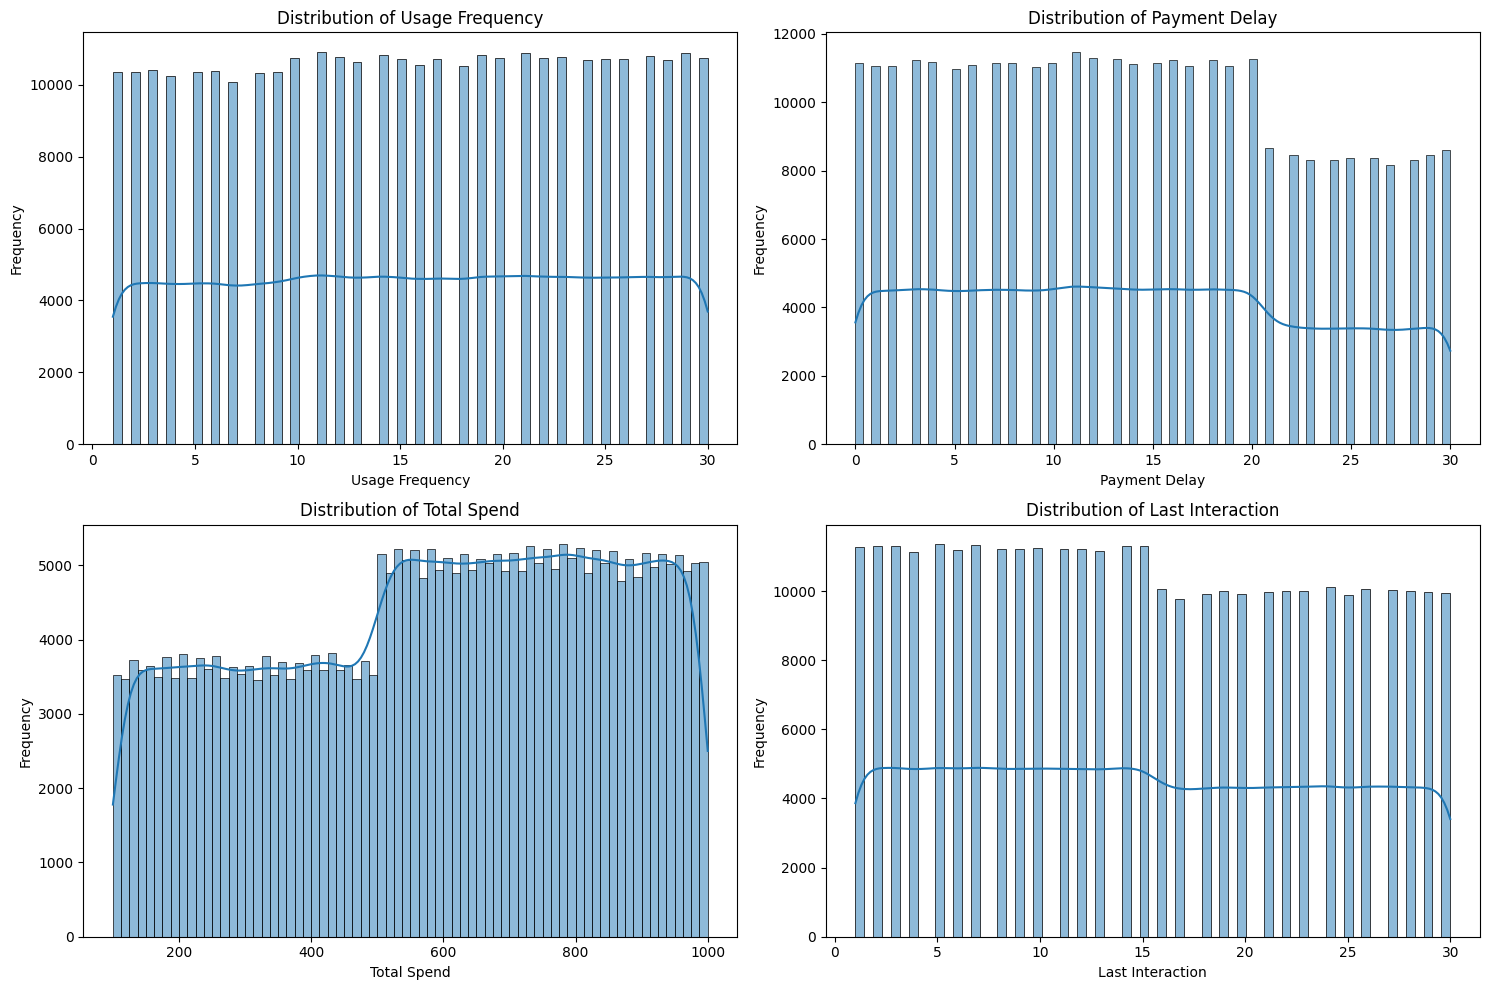

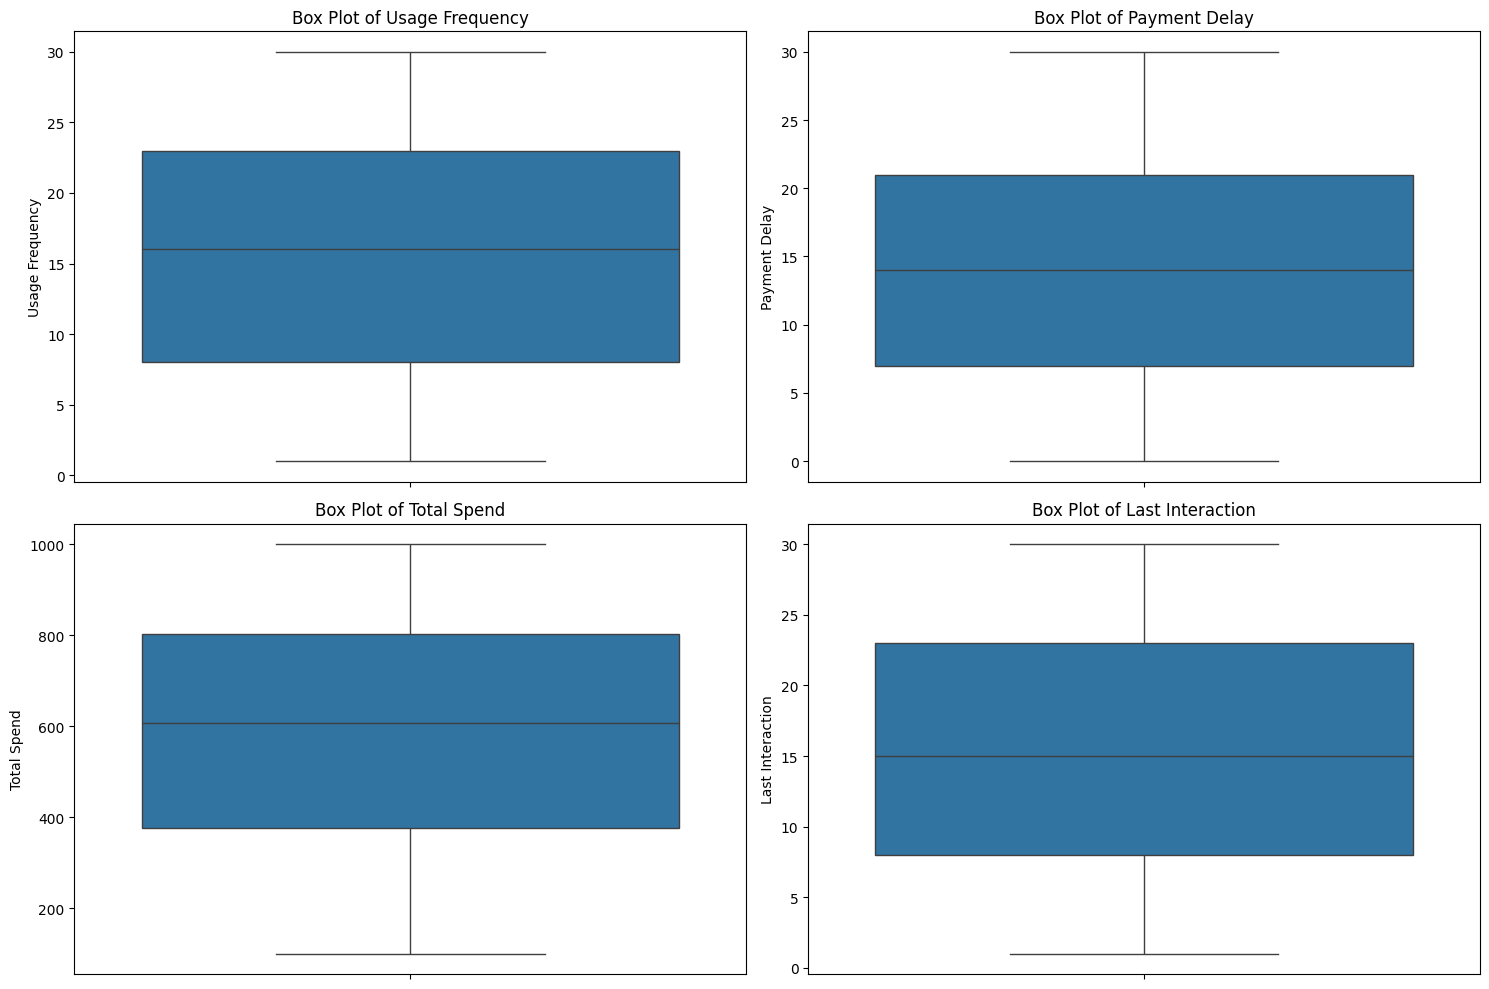

/tmp/ipykernel_791/291277493.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')
/tmp/ipykernel_791/291277493.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')
/tmp/ipykernel_791/291277493.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')
/tmp/ipykernel_791/291277493.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

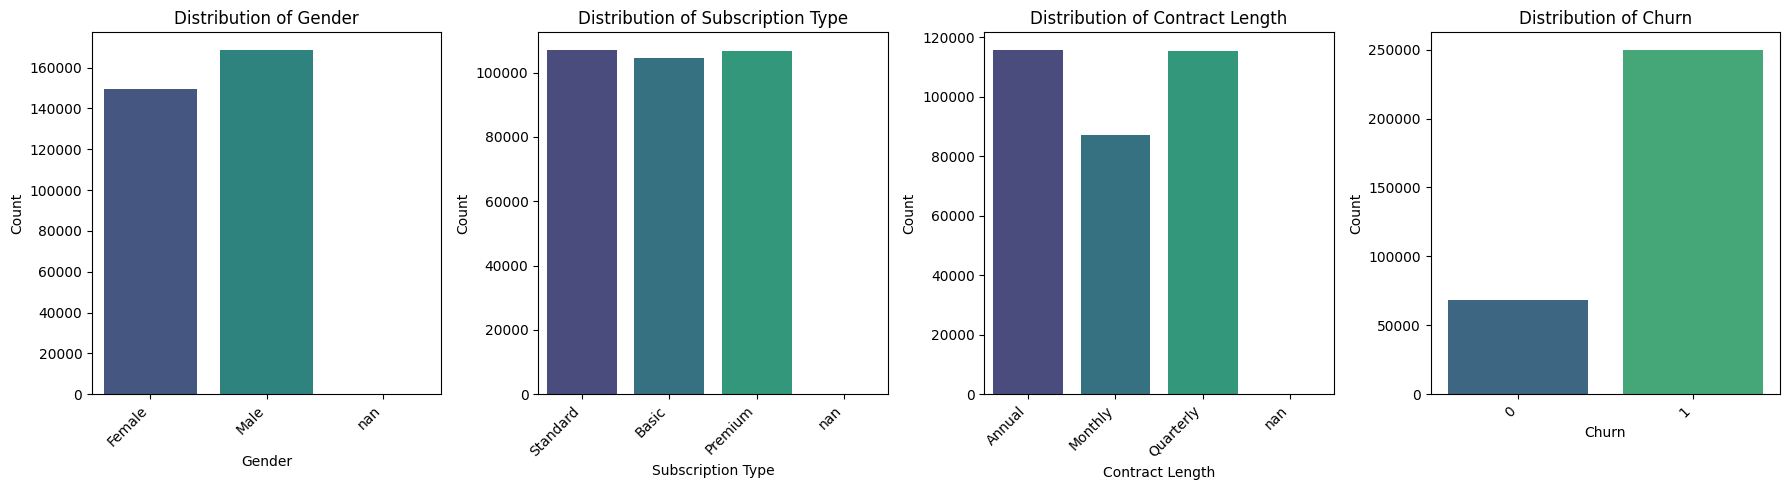

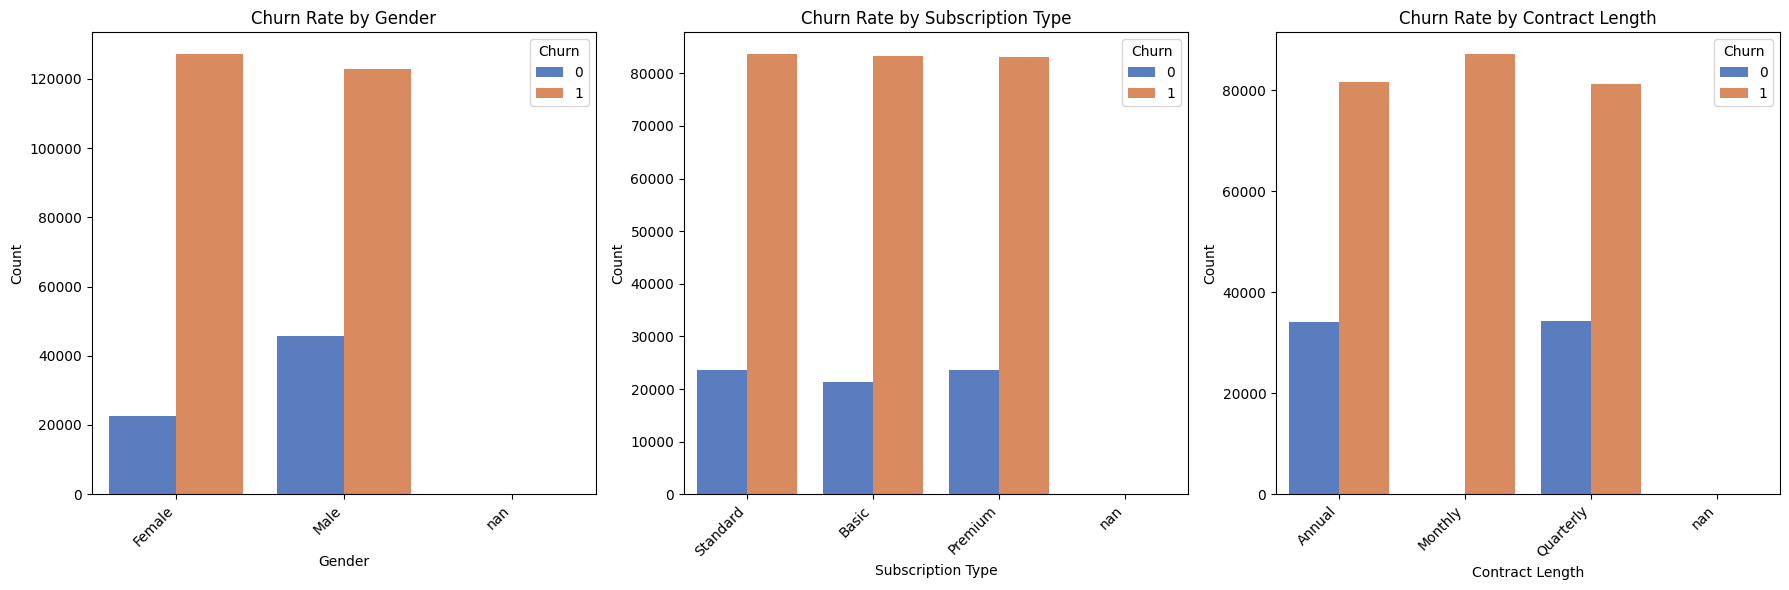

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = ['Usage Frequency', 'Payment Delay', 'Total Spend', 'Last Interaction']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i) # Create a 2x2 grid of subplots
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i) # Create a 2x2 grid of subplots
    sns.boxplot(y=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

categorical_features = ['Gender', 'Subscription Type', 'Contract Length', 'Churn']

plt.figure(figsize=(18, 5))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(1, len(categorical_features), i) # Create subplots based on number of features
    sns.countplot(x=feature, data=df, palette='viridis')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

categorical_features_for_churn_comparison = ['Gender', 'Subscription Type', 'Contract Length']

plt.figure(figsize=(18, 6))
for i, feature in enumerate(categorical_features_for_churn_comparison, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=feature, hue='Churn', data=df, palette='muted')
    plt.title(f'Churn Rate by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
